In [1]:
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import matplotlib as mpl
from matplotlib import font_manager
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, TensorDataset
import math
import os
import re
import json
import numpy as np
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
# data_path = f'/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/{dataset}'
data_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/filtered_patient6.csv'
filtered_df = pd.read_csv(data_path)

# 注册中文字体到matplotlib
font_path = "/System/Library/Fonts/Supplemental/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False


/opt/anaconda3/envs/naojiye/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


matplotlib 识别的字体名: Songti SC


In [3]:
# 提取当前数据集的数字
def extract_integers(s: str):
    """
    从字符串中提取所有整数，返回一个 int 列表
    """
    return list(map(int, re.findall(r"\d+", s)))


In [4]:
def label_encoding(filtered_df, data_path):
    columns_to_change1 = [item for item in filtered_df if item.endswith('_定性')]
    columns_to_change2 = [item for item in filtered_df if item.endswith('_描述性')]

    # 对每个object类型的列进行Label Encoding
    object_columns = columns_to_change1+columns_to_change2
    if 'filtered_patient1' in data_path or 'filtered_patient2' in data_path or 'filtered_patient5' in data_path:
        object_columns.remove('脑脊液_透明度_描述性')
        object_columns.remove('脑脊液_蛋白定性_定性')

    features_to_change = [ '血_抗双链DNA抗体_定性', '血_抗核抗体_定性', '血_抗胞浆型中性粒细胞抗体_定性', '血_抗核周型中性粒细胞抗体_定性', '血_梅毒非特异性抗体_定性', '血_梅毒螺旋体抗体_定性',
                        '血_人类免疫缺陷病毒抗体_定性', '血_不规则抗体_定性', '血_直接抗人球蛋白试验_定性', '血_结核感染T细胞检测_定性', '血_人类免疫缺陷病毒P24抗原_定性', '血_M蛋白_描述性']

    if 'filtered_patient2' in data_path or 'filtered_patient4' in data_path:
        for i in features_to_change:
            object_columns.remove(i)

    le_dict = {}
    for col in object_columns:
        le = LabelEncoder()
        # 处理空值：先用'unknown'填充，再进行编码
        filtered_df[col] = filtered_df[col].fillna('unknown')
        filtered_df[col] = le.fit_transform(filtered_df[col].astype(str))  # 确保没有NaN，否则会报错
        le_dict[col] = le  # 保存编码器，后续可能用于推理
    
    return filtered_df
    

In [5]:

# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names

    
    # filtered_df.columns = clean_feature_names_simple(filtered_df.columns)
    # print("清洗后的列名:", filtered_df.columns.tolist())



In [6]:
def train_and_validate(model, train_loader, val_loader, lr, epochs=50, patience=5):
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    best_auc = 0.0
    patience_counter = 0

    history = {"train_loss": [], "val_loss": [], "val_auc": []}
    best_model_state = None

    for epoch in range(epochs):
       
        # ---------- 训练 ----------
        model.train()
        train_loss = 0.0
        for xb, yb in train_loader:
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()
            train_loss += loss.item() * xb.size(0)
        avg_train_loss = train_loss / len(train_loader.dataset)

        # ---------- 验证 ----------
        model.eval()
        val_loss = 0.0
        y, y_pred = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                pred = model(xb)
                loss = criterion(pred, yb)
                val_loss += loss.item() * xb.size(0)
                y.extend(yb.numpy())
                y_pred.extend(pred.numpy())
        avg_val_loss = val_loss / len(val_loader.dataset)

        auc = roc_auc_score(y, y_pred)

        # 记录历史
        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(avg_val_loss)
        history["val_auc"].append(auc)

        # ---------- EarlyStopping ----------
        best_result = {}
        if auc > best_auc:
            best_auc = auc
            patience_counter = 0
            best_model_state = model.state_dict()
            torch.save(best_model_state, "best_model.pth")
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break
        
    return best_auc, history, best_model_state

In [7]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

def bootstrap_auc_ci(y_true, y_score, B=1000, seed=2025, return_distribution=False):
    """
    Bootstrap percentile CI for ROC-AUC with stratified resampling on the test set.
    y_true: 1D array of {0,1}
    y_score: 1D array of predicted probabilities for class 1
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # 原始整套测试集点估计
    auc_point = roc_auc_score(y_true, y_score)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n_pos, n_neg = len(pos_idx), len(neg_idx)

    aucs = np.empty(B, dtype=float)
    for b in range(B):
        # 分层有放回采样，保持类样本量不变
        boot_pos = rng.choice(pos_idx, size=n_pos, replace=True)
        boot_neg = rng.choice(neg_idx, size=n_neg, replace=True)
        boot_idx = np.concatenate([boot_pos, boot_neg])

        # 计算本次 AUC
        aucs[b] = roc_auc_score(y_true[boot_idx], y_score[boot_idx])

    # 百分位 CI
    lower, median, upper = np.percentile(aucs, [2.5, 50.0, 97.5])
    if return_distribution:
        return {"point": auc_point, "median": median, "ci95": (lower, upper), "all": aucs}
    else:
        return {"point": auc_point, "median": median, "ci95": (lower, upper)}



In [8]:
def train(X_train, train_dataset, val_dataset, key):
    # 定义 Optuna 目标函数
    def objective(trial):
        n_layers = trial.suggest_int("n_layers", 1, 2)
        hidden_size = trial.suggest_categorical("hidden_size", [16, 32, 64, 128])
        dropout_rate = trial.suggest_float("dropout", 0.2, 0.6)
        lr = trial.suggest_float("lr", 1e-6, 1e-3, log=True)
        batch_size = trial.suggest_categorical("batch_size", [8, 16, 32, 64])

        # 构建 MLP
        layers = []
        in_features = X_train.shape[1]
        for i in range(n_layers):
            layers.append(nn.Linear(in_features, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            in_features = hidden_size
        layers.append(nn.Linear(in_features, 1))
        layers.append(nn.Sigmoid())
        model = nn.Sequential(*layers)

        # DataLoader
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

        # 训练 + 验证 + EarlyStopping
        auc, _ , _ = train_and_validate(model, train_loader, val_loader, lr, epochs=50, patience=5)

        return auc
    
    # 创建 Optuna 研究
    study = optuna.create_study(direction="maximize",sampler=optuna.samplers.TPESampler(seed=42))
   

    # 运行优化
    print("开始超参数优化...")
    study.optimize(objective, n_trials=50)

    # 输出最佳结果
    print("\n优化完成!")
    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    best_trial = study.best_trial
    print(f"  Best AUC: {best_trial.value:.4f}")  # 转换回 AUC
    print("  Best params: ")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")

    # 使用最佳参数重新训练最终模型
    print("\n使用最佳参数训练最终模型...")
    
    layers = []
    in_features = X_train.shape[1]
    best_params = best_trial.params
    for i in range(best_params["n_layers"]):
        layers.append(nn.Linear(in_features, best_params["hidden_size"]))
        layers.append(nn.ReLU())
        layers.append(nn.Dropout(best_params["dropout"]))
        in_features = best_params["hidden_size"]
    layers.append(nn.Linear(in_features, 1))
    layers.append(nn.Sigmoid())
    best_model = nn.Sequential(*layers)

    # DataLoader
    train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=best_params["batch_size"], shuffle=False)
    
    auc, history, best_state = train_and_validate(best_model, train_loader, val_loader, best_params["lr"], epochs=50, patience=5)
    
    best_params = best_trial.params
    best_params['random_state'] = 42

    return [best_model,best_trial.params,best_params]

# 在各个数据集上评估最终模型
def evaluate_model(model, test_loader, dataset_name):
    model.load_state_dict(torch.load("best_model.pth"))


    model.eval()
    y_true, y_pred_prob = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            pred = model(xb)
            y_true.extend(yb.numpy())
            y_pred_prob.extend(pred.numpy())

    y = np.array(y_true)
    y_pred_proba = np.array(y_pred_prob)

    # 最佳阈值
    best_thresh, best_f1 = 0.5, 0
    for thresh in np.arange(0.01, 0.99, 0.01):
        pred_val = (y_pred_proba > thresh).astype(int)
        f1 = f1_score(y, pred_val)
        if f1 > best_f1:
            best_thresh, best_f1 = thresh, f1
     
    y_pred = (y_pred_proba >= best_thresh).astype(int)
    
    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred, zero_division=0)
    f1 = f1_score(y, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y, y_pred_proba)
    
    res_auc = bootstrap_auc_ci(y, y_pred_proba, B=1000, seed=2025)
    print(f"AUC = {res_auc['point']:.3f} "
        f"(95% CI {res_auc['ci95'][0]:.3f}–{res_auc['ci95'][1]:.3f})")

    # res_pr = bootstrap_prauc_ci(y_true_test, y_score_test, B=1000, seed=2025)
    # print(f"PR-AUC = {res_pr['point']:.3f} "
    #     f"(95% CI {res_pr['ci95'][0]:.3f}–{res_pr['ci95'][1]:.3f})")

    print(f"\n{dataset_name} 集评估结果:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba,
        'CI': (round(res_auc['ci95'][0],4),round(res_auc['ci95'][1],4))
    }


In [9]:
def draw_result(y_val, y_test, val_results, test_results, key, current_dataset):

    # 绘制ROC曲线
    plt.figure(figsize=(10, 8))

    # 计算各数据集的ROC曲线
    fpr_val, tpr_val, thresholds = roc_curve(y_val, val_results['y_pred_proba'])
    fpr_test, tpr_test, thresholds = roc_curve(y_test, test_results['y_pred_proba'])

    pd.DataFrame({
        "fpr": fpr_test,
        "tpr": tpr_test,
        "threshold": thresholds  
    }).to_csv(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/ROC/MLP/{key}/Dataset{current_dataset}_roc_curve.csv", index=False)


    # 绘制ROC曲线
    plt.plot(fpr_val, tpr_val, color='blue', lw=2, 
            label=f'验证集 AUC = {val_results["auc"]:.4f}')
    plt.plot(fpr_test, tpr_test, color='red', lw=2, 
            label=f'测试集 AUC = {test_results["auc"]:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{key} - MLP ROC曲线', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/MLP/ROC_AUC/Dataset{current_dataset}/{key}ROC-AUC.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

    model = key
    data_to_append = {'val_accuracy':round(val_results['accuracy'],4),'val_precision':round(val_results['precision'],4),'val_recall':round(val_results['recall'],4),'val_f1':round(val_results['f1'],4),'roc_auc_val':round(val_results['auc'],4),'val_CI':val_results['CI'],
                    'test_accuracy':round(test_results['accuracy'],4),'test_precision':round(test_results['precision'],4),'test_recall':round(test_results['recall'],4),'test_f1':round(test_results['f1'],4),'roc_auc_test':round(test_results['auc'],4),'test_CI':test_results['CI']}
    # JSON 文件路径
    json_file = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/model_data4/MLP_data.json"

    # 如果文件存在，先读取已有数组，否则初始化为空列表
    if os.path.exists(json_file):
        with open(json_file, "r", encoding="utf-8") as f:
            try:
                existing_data = json.load(f)
                if f'MLP_Dataset{current_dataset}' not in existing_data:
                    existing_data[f'MLP_Dataset{current_dataset}'] = {}
            except json.JSONDecodeError:
                existing_data = {f'MLP_Dataset{current_dataset}':{}}
    else:
        existing_data = {f'MLP_Dataset{current_dataset}':{}}

    # 追加新的数据
    existing_data[f'MLP_Dataset{current_dataset}'][model] = data_to_append

    # 写回 JSON 文件
    with open(json_file, "w", encoding="utf-8") as f:
        json.dump(existing_data, f, ensure_ascii=False, indent=4)



In [10]:
def draw_shap(final_model, X_train, X_test, current_dataset, key):
    # ---------------- SHAP 分析 -----------------

    X_train_np = X_train.values.astype("float32")
    X_test_np = X_test.values.astype("float32")


    final_model.load_state_dict(torch.load("best_model.pth"))
    final_model.eval() 

    def predict_fn(x):
    # x 是 numpy array，形状 (n_samples, n_features)
        x_tensor = torch.tensor(x, dtype=torch.float32)
        with torch.no_grad():
            preds = final_model(x_tensor).detach()         # (n_samples, 1)
            preds = preds.numpy().reshape(-1)      # 变成 (n_samples,)
        return preds

    background = X_train_np[:100]
    explainer = shap.KernelExplainer(predict_fn, background)
    shap_values = explainer.shap_values(X_test_np[:50], nsamples=200)

    
    print(f"\n===== SHAP 特征重要性 (柱状图):  =====")
    plt.title(f"{key}特征重要性(柱状图)", fontsize=16, fontweight='bold')
    plt.tight_layout()
    shap.summary_plot(shap_values, X_test_np[:50], plot_type="bar", show=False, feature_names = X_train.columns)
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/MLP/shap/Dataset{current_dataset}/{key}shap柱状图.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    # print(f"/Users/yanjieni/Desktop/脑脊液/naojiye/images/XGBoost/shap/Dataset{current_dataset}/{key}shap柱状图.png")
    plt.show()

    plt.title(f"{key}特征重要性(柱状图)", fontsize=16, fontweight='bold')
    plt.tight_layout()

    print(f"\n===== SHAP 特征分布 (蜂群图): =====")
    shap.summary_plot(shap_values, X_test_np[:50], show=False, feature_names = X_train.columns)
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/MLP/shap/Dataset{current_dataset}/{key}shap蜂群图.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()



In [11]:

# data_path = '/Users/yanjieni/Desktop/脑脊液/naojiye/data/final_data/filtered_patient8.csv'

filtered_df = label_encoding(filtered_df, data_path)
# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})



In [12]:
import random

def set_seed(seed=42):
    random.seed(seed)                  # Python 内置随机数
    np.random.seed(seed)               # Numpy 随机数
    torch.manual_seed(seed)            # CPU 随机数
    torch.cuda.manual_seed(seed)       # 当前GPU
    torch.cuda.manual_seed_all(seed)   # 所有GPU（多卡）
    torch.backends.cudnn.deterministic = True   # 保证卷积等结果确定
    torch.backends.cudnn.benchmark = False      # 避免自动优化引入的不确定性

[I 2025-11-18 18:37:25,586] A new study created in memory with name: no-name-8d3cc53f-7932-4b38-a6e4-a0e71c07ce76


开始超参数优化...


[I 2025-11-18 18:37:30,956] Trial 0 finished with value: 0.6723809523809524 and parameters: {'n_layers': 1, 'hidden_size': 16, 'dropout': 0.26239780813448105, 'lr': 1.493656855461763e-06, 'batch_size': 8}. Best is trial 0 with value: 0.6723809523809524.


Early stopping at epoch 6


[I 2025-11-18 18:37:33,404] Trial 1 finished with value: 0.5888888888888889 and parameters: {'n_layers': 2, 'hidden_size': 16, 'dropout': 0.3216968971838151, 'lr': 3.752055855124284e-05, 'batch_size': 32}. Best is trial 0 with value: 0.6723809523809524.
[I 2025-11-18 18:37:36,742] Trial 2 finished with value: 0.6904761904761905 and parameters: {'n_layers': 1, 'hidden_size': 64, 'dropout': 0.40569377536544465, 'lr': 5.987474910461405e-05, 'batch_size': 16}. Best is trial 2 with value: 0.6904761904761905.
[I 2025-11-18 18:37:37,346] Trial 3 finished with value: 0.6126984126984127 and parameters: {'n_layers': 2, 'hidden_size': 16, 'dropout': 0.47369321060486275, 'lr': 2.091498132903561e-05, 'batch_size': 64}. Best is trial 2 with value: 0.6904761904761905.


...

Early stopping at epoch 48


[I 2025-11-18 18:39:48,345] Trial 48 finished with value: 0.7815873015873016 and parameters: {'n_layers': 1, 'hidden_size': 128, 'dropout': 0.4514107577606861, 'lr': 0.00018171610238824408, 'batch_size': 8}. Best is trial 32 with value: 0.8177777777777778.


Early stopping at epoch 14


[I 2025-11-18 18:39:48,874] Trial 49 finished with value: 0.7434920634920635 and parameters: {'n_layers': 2, 'hidden_size': 32, 'dropout': 0.21429399907378452, 'lr': 0.00044902585127706737, 'batch_size': 64}. Best is trial 32 with value: 0.8177777777777778.


Early stopping at epoch 7

优化完成!
Number of finished trials:  50
Best trial:
  Best AUC: 0.8178
  Best params: 
    n_layers: 1
    hidden_size: 16
    dropout: 0.24735575334743212
    lr: 0.0006915450448817846
    batch_size: 16

使用最佳参数训练最终模型...
AUC = 0.756 (95% CI 0.669–0.836)

验证 集评估结果:
Accuracy: 0.6556
Precision: 0.2923
Recall: 0.7600
F1-Score: 0.4222
AUC: 0.7559
AUC = 0.747 (95% CI 0.655–0.829)

测试 集评估结果:
Accuracy: 0.6382
Precision: 0.2973
Recall: 0.8800
F1-Score: 0.4444
AUC: 0.7471


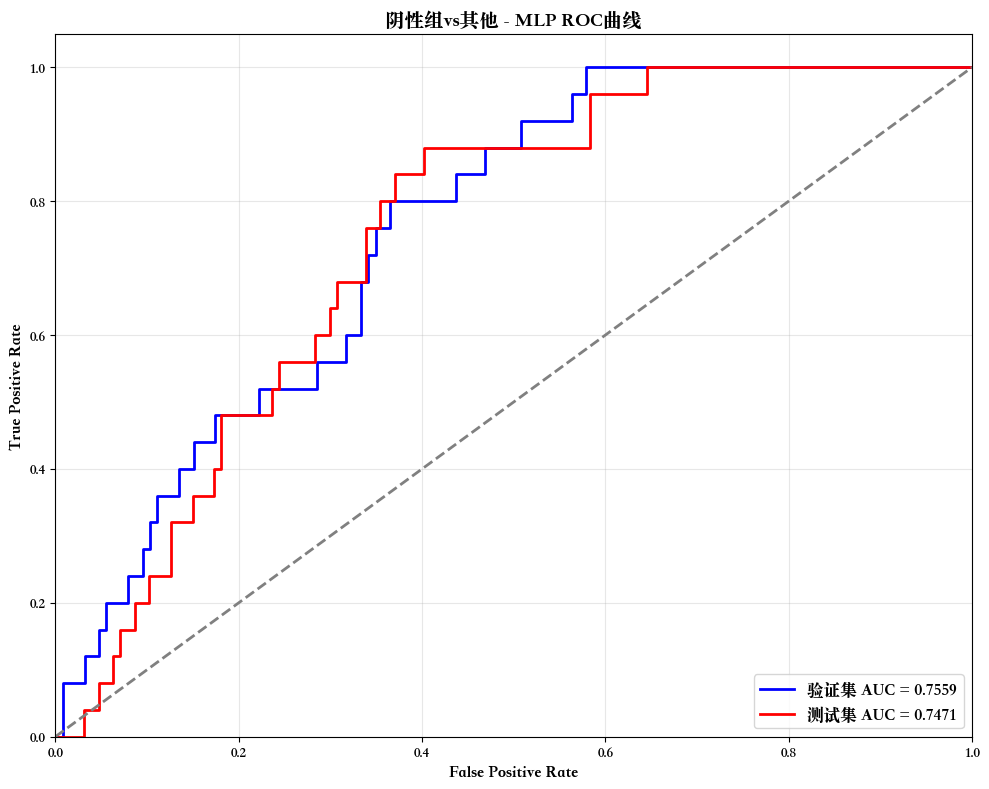

100%|██████████| 50/50 [00:00<00:00, 150.90it/s]
/var/folders/1n/vp7g9rg94717gbh8l98slmfh0000gn/T/ipykernel_17741/2549470248.py:27: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_np[:50], plot_type="bar", show=False, feature_names = X_train.columns)



===== SHAP 特征重要性 (柱状图):  =====


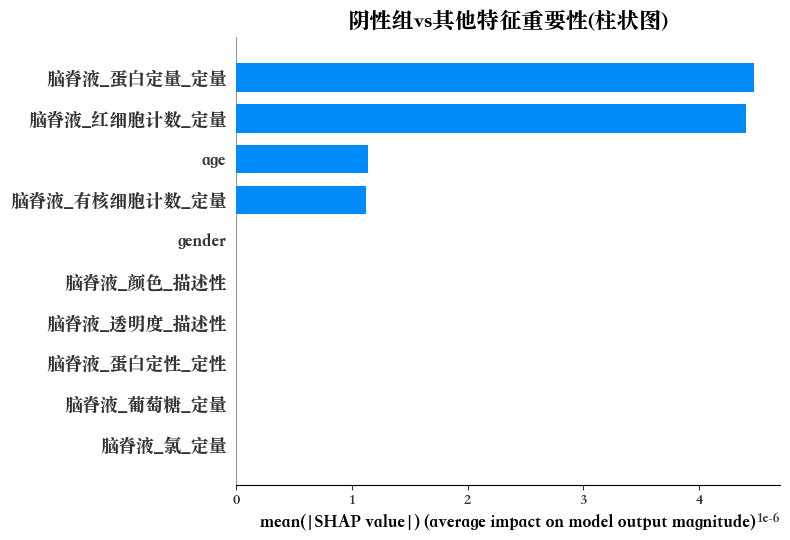


===== SHAP 特征分布 (蜂群图): =====


/var/folders/1n/vp7g9rg94717gbh8l98slmfh0000gn/T/ipykernel_17741/2549470248.py:36: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_np[:50], show=False, feature_names = X_train.columns)


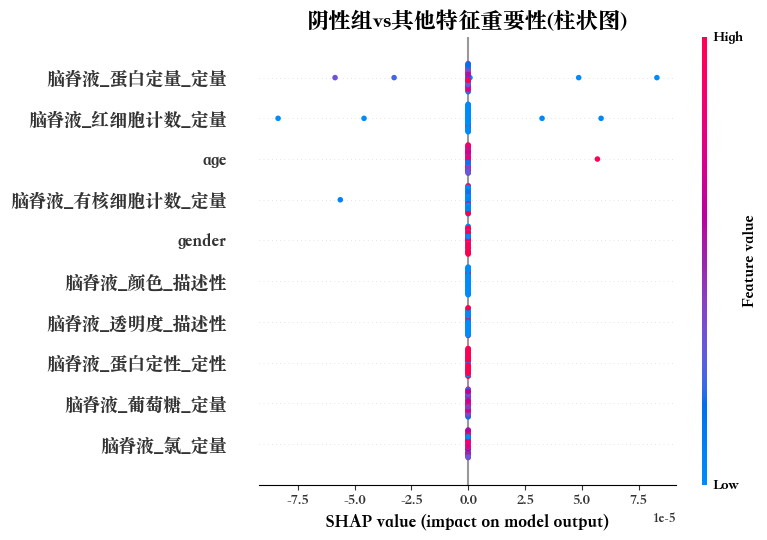

In [13]:
set_seed(42)
screen_data = {
    '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    # '感染性脑膜炎vs非感染性脑膜炎': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    # '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    # '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    # '结核性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    # '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    # '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    # '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    # '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

def delete_same_col(df):
    same_cols = df.nunique() == 1
    d = dict(same_cols)
    none_feature = []
    for keys, items in d.items():
        if items == True:
            none_feature.append(keys)
    return df.drop(none_feature, axis=1)

def run_model(key, item, selected_df, current_dataset):
    # 筛选需要的组别
    selected_df = selected_df[selected_df['分组'].isin(item[0])]
    # print(selected_df.isna().sum())
    selected_df = selected_df.fillna(selected_df.mean(numeric_only=True))
    
    # 删除数值一样的列  
    selected_df = delete_same_col(selected_df)

    # print(selected_df["分组"])
    # 选择特征 将数据正例和反例平均分配
    filter_1 = selected_df[selected_df["分组"].isin(item[1])]
    filter_2 = selected_df[selected_df["分组"].isin(item[2])]

    # filter_2 = filter_2.fillna(filter_2.mean(numeric_only=True))    
    
    X_1 = filter_1[list(filter_1.columns)[:-2]]
    X_2 = filter_2[list(filter_2.columns)[:-2]]
    # print(X_1.columns)
    # 标签（分组，1 类与其他类）
    y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
    y_2 = (filter_2['分组'].isin(item[1])).astype(int) 

    # 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
    X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
    X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

    X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
    X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

    # 将正例与反例拼接
    X_train = pd.concat([X_train_1,X_train_2])
    y_train = pd.concat([y_train_1,y_train_2])

    X_val = pd.concat([X_val_1,X_val_2])
    y_val = pd.concat([y_val_1,y_val_2])

    X_test = pd.concat([X_test_1,X_test_2])
    y_test = pd.concat([y_test_1,y_test_2])

    scaler = StandardScaler()
    X_trian_scaled = scaler.fit_transform(X_train.values.astype("float32")).astype(np.float32)
    X_val_scaled = scaler.fit_transform(X_val.values.astype("float32")).astype(np.float32)
    X_test_scaled = scaler.fit_transform(X_test.values.astype("float32")).astype(np.float32)

    X_train_tensor = torch.tensor(X_trian_scaled)
    y_train_tensor = torch.tensor(y_train.values.astype("float32")).unsqueeze(1)

    X_val_tensor = torch.tensor(X_val_scaled)
    y_val_tensor = torch.tensor(y_val.values.astype("float32")).unsqueeze(1)

    X_test_tensor = torch.tensor(X_test_scaled)
    y_test_tensor = torch.tensor(y_test.values.astype("float32")).unsqueeze(1)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)


    # 得到最优模型
    result = train(X_train, train_dataset, val_dataset, key)
    final_model = result[0]
    # 评估验证集和测试集
    val_results = evaluate_model(final_model, val_dataset, "验证")
    test_results = evaluate_model(final_model, test_dataset, "测试")    
    
    # 绘制ROC——AUC图 并存储数据
    draw_result(y_val, y_test, val_results, test_results, key, current_dataset)

    # 绘制shap图
    draw_shap(final_model, X_train, X_test, current_dataset, key)
    return result[2]

    
if extract_integers(data_path)[-1] == 2:
    selected_features = {
        '阴性组vs其他': filtered_df[['脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量','血_嗜酸性粒细胞百分比_定量','血_葡萄糖空腹_定量','血_结核感染T细胞检测_定性','血_乙型肝炎病毒核心抗体.IgM_定量', '分组', '组名']],
        '感染性脑膜炎vs非感染性脑膜炎': filtered_df[['脑脊液_单个核细胞百分比_定量','脑脊液_葡萄糖_定量', '脑脊液_激活淋巴细胞_定量','脑脊液_多个核细胞百分比_定量', '分组', '组名']],
        '细菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_多个核细胞百分比_定量','血_C反应蛋白_定量','脑脊液_有核细胞计数_定量','血_抗凝血酶III_定量','血_血小板分布宽度_定量','血_单核细胞计数_定量', '血_细胞.CD3+CD8+百分比_定量','分组', '组名']],
        '病毒性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_葡萄糖_定量','脑脊液_中性粒细胞百分比_定量','血_肌酸激酶_定量', '血_肾小球滤过率_定量', '血_免疫球蛋白E_定量','血_细胞.CD3-CD16+CD56+百分比_定量','脑脊液_多个核细胞百分比_定量','脑脊液_蛋白定量_定量','分组', '组名']],
        '结核性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_结核感染T细胞检测_定性','脑脊液_氯_定量','血_结核感染T细胞测试管_定量','脑脊液_葡萄糖_定量','血_淋巴细胞计数_定量','血_血小板分布宽度_定量', '血_铁蛋白_定量', '血_游离T4_定量', '分组', '组名']],
        '真菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_细胞.CD3-CD19+百分比_定量','血_不规则抗体_定性','血_梅毒非特异性抗体_定性', '脑脊液_有核细胞计数_定量', '分组', '组名']],
        '肿瘤性脑膜炎vs其他': filtered_df[['脑脊液_蛋白定量_定量', '脑脊液_葡萄糖_定量', '脑脊液_多个核细胞百分比_定量', '脑脊液_淋巴细胞百分比_定量', 'age','分组', '组名']],
        '自身免疫性脑膜炎vs其他': filtered_df[['血_丙型肝炎病毒抗体_定量','脑脊液_葡萄糖_定量','血_结核感染T细胞测试管_定量','血_铁蛋白_定量','脑脊液_蛋白定量_定量','血_D-二聚体_定量','血_乙型肝炎病毒核心抗体.IgM_定量','age','分组', '组名']],
        '病毒性脑膜炎vs病毒性脑炎': filtered_df[['脑脊液_有核细胞计数_定量','血_降钙素原_定量','血_同型半胱氨酸_定量','血_细胞.CD3+CD4+百分比_定量','血_血小板分布宽度_定量', '血_细胞.CD3+CD8+百分比_定量', '血_前白蛋白_定量', '血_铁蛋白_定量', '分组', '组名']]
    }

current_dataset = extract_integers(data_path)[-1]
for key, item in screen_data.items():
    # 训练模型 - 数据集1-8
    
    filtered_df2 = filtered_df.copy()
    result_para = run_model(key, item, filtered_df2, current_dataset)

    # 训练模型 - 精选特征数据集
    if current_dataset == 2:
        run_model(key, item, selected_features[key], 9)

     
        